In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import plotly.express as px
import plotly.graph_objects as go

# 1 Manual Data "X1" & "X2" vs "y"

In [2]:
data = {
    "X1" : [10, 12, 10, 9, 15, 10, 14, 15, 15, 16],
    "X2" : [8, 12, 9, 9, 11, 9, 11, 14, 11, 12],
    "y" : [10, 10, 10, 9, 11, 11, 9, 9, 10, 10]
}

df = pd.DataFrame(data)

df

,X1,X2,y
0,10,8,10
1,12,12,10
2,10,9,10
3,9,9,9
4,15,11,11
5,10,9,11
6,14,11,9
7,15,14,9
8,15,11,10
9,16,12,10


## a) Print first 5 rows of data, Display scatter plot of data

In [3]:
df.head()

,X1,X2,y
0,10,8,10
1,12,12,10
2,10,9,10
3,9,9,9
4,15,11,11


In [4]:
fig = px.scatter_3d(
    df,
    x='X1',
    y='X2',
    z='y',
    title="3D Scatter Plot of X1, X2 and y"
)

fig.show()

## b) Calculate (using formula) and print regression coefficients b0, b1 and b2

In [6]:
x1 = df["X1"]
x2 = df["X2"]
y = df["y"]

x1_mean = np.mean(x1)
x2_mean = np.mean(x2)
y_mean = np.mean(y)

sum_x1_sq = np.sum(x1**2)
sum_x2_sq = np.sum(x2**2)
sum_x1x2 = np.sum(x1*x2)

sum_x1y = np.sum(x1*y)
sum_x2y = np.sum(x2*y)

b1 = ( (sum_x2_sq * sum_x1y) - (sum_x1x2 * sum_x2y) ) / ( (sum_x1_sq * sum_x2_sq) - (sum_x1x2 ** 2) )

b2 = ( (sum_x1_sq * sum_x2y) - (sum_x1x2 * sum_x1y) ) / ( (sum_x1_sq * sum_x2_sq) - (sum_x1x2 ** 2) )

b0 = y_mean - b1*x1_mean - b2*x2_mean

print("b0 =", b0)
print("b1 =", b1)
print("b2 =", b2)

b0 = 0.2907722195240403
b1 = 0.18575111144319498
b2 = 0.6857324317256324


## c) Display regression line equation

In [7]:
print("Regression Equation:")
print(f"y = {b0:.3f} + ({b1:.3f})X1 + ({b2:.3f})X2")

Regression Equation:
y = 0.291 + (0.186)X1 + (0.686)X2


## d) Calculate and print coefficient of determination (R squared, Residual sum of squares (RSS), and RMSE)

In [8]:
y_cap = b0 + b1*x1 + b2*x2

RSS = np.sum((y - y_cap)**2)

TSS = np.sum((y - y_mean)**2)

R2 = 1 - (RSS/TSS)

RMSE = np.sqrt(np.mean((y - y_cap)**2))

print("R² =", R2)
print("RSS =", RSS)
print("RMSE =", RMSE)

R² = -6.193215430378587
RSS = 35.24675560885508
RMSE = 1.8774119315924005


## e) Plot regression line

In [9]:
# create grid
x1_range = np.linspace(df.X1.min(), df.X1.max(), 20)
x2_range = np.linspace(df.X2.min(), df.X2.max(), 20)

x1_grid, x2_grid = np.meshgrid(x1_range, x2_range)

# regression plane
y_grid = b0 + b1*x1_grid + b2*x2_grid

fig = go.Figure()

# data points
fig.add_trace(go.Scatter3d(
    x=df["X1"],
    y=df["X2"],
    z=df["y"],
    mode='markers',
    marker=dict(size=6, color='red'),
    name="Actual Data Points"
))

# regression surface
fig.add_trace(go.Surface(
    x=x1_grid,
    y=x2_grid,
    z=y_grid,
    colorscale='Viridis',
    opacity=0.7,
    name="Regression Surface",
    colorbar=dict(title="Predicted Y")
))

fig.update_layout(
    title="3D Multiple Linear Regression Plane",
    scene=dict(
        xaxis_title="X1",
        yaxis_title="X2",
        zaxis_title="y"
    ),
    legend=dict(
        title="Legend",
        x=0.01,
        y=0.99
    )
)

fig.show()

## f) Predict the value of y given x1=10, x2=11

In [10]:
x1_pred = 10
x2_pred = 11

y_pred = b0 + b1 * x1_pred + b2 * x2_pred

print(f"Predicted Y for given values is: {y_pred:.3f}")

Predicted Y for given values is: 9.691


# 2. Inbuilt functions in Python

## a) Import the packages

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

## b) Read dataset

In [3]:
adv_ds = pd.read_csv('data/Advertising.csv')

adv_ds.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


## c) Divide data into training and testing split

In [4]:
X = adv_ds[['TV','Radio','Newspaper']]
y = adv_ds['Sales']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (160, 3)
Testing data shape: (40, 3)


## d) Create an instance of the class LinearRegression, which will represent the regression model

In [5]:
model = LinearRegression()

## e) Fit the model for training data

In [6]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## f) Get coefficients of regression and coefficient of determination from the model

In [7]:
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

print("R² Score (Testing):", model.score(X_test, y_test))

Intercept: 4.714126402214127
Coefficients: [0.05450927 0.10094536 0.00433665]
R² Score (Testing): 0.9059011844150826


## g) Apply the model for predictions on testing data. Show the residual error plot for training(with green color dots), testing data (blue color) and zero residual error line

In [8]:
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

train_residuals = y_train - train_pred
test_residuals = y_test - test_pred

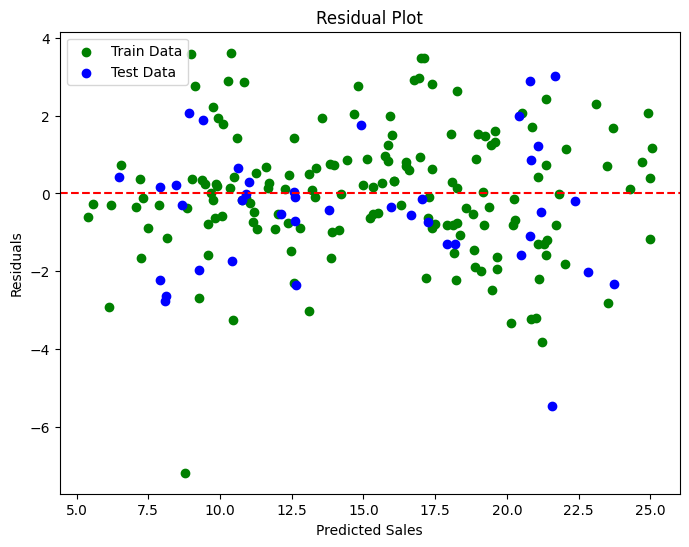

In [9]:
plt.figure(figsize=(8,6))

plt.scatter(train_pred, train_residuals, color='green', label='Train Data')
plt.scatter(test_pred, test_residuals, color='blue', label='Test Data')

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.legend()
plt.show()